# 🌦️ Smart Weather Prediction System

### Predicting the weather for **any future date** with Time Series Forecasting

---

**Project type:** Time Series Forecasting + Binary Classification

**The question this project answers:** *"Will it rain in Delhi on 15 September?"*

That is a genuinely harder question than the usual beginner weather project,
which asks you to type in today's humidity and pressure. Nobody knows
September's humidity yet — so we have to **forecast the weather parameters
first**, and only then decide whether those parameters mean rain.

---

### 📑 Contents

| # | Section |
|---|---------|
| 1 | Setup and imports |
| 2 | Data collection — 10 years of real ERA5 weather |
| 3 | Data preprocessing |
| 4 | Exploratory Data Analysis |
| 5 | Feature engineering — how to describe *any* date |
| 6 | The forecasting problem and the baseline |
| 7 | Model 1 — Random Forest |
| 8 | Model 2 — XGBoost |
| 9 | Model 3 — Prophet |
| 10 | Model 4 — ARIMA (SARIMAX + Fourier) |
| 11 | Model 5 — LSTM (PyTorch) |
| 12 | Model comparison — MAE, RMSE, R² |
| 13 | Rolling-origin backtesting |
| 14 | The Rain / No Rain classifier |
| 15 | Feature importance |
| 16 | The complete prediction system |
| 17 | Conclusions |

> **Before running:** execute `python train.py` once from the project root.
> It downloads the data and trains every model (about 4 minutes).

---
## 1. Setup and imports

The notebook lives in `notebook/`, so the first cell steps up to the project
root. That way every path in the notebook matches the paths used by `app.py`
and `train.py`.

In [1]:
import os
import sys
import json
import warnings

# Step up to the project root so `import utils` works and paths line up.
if os.path.basename(os.getcwd()) == "notebook":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.max_columns", None)

print("Working folder:", os.getcwd())

Working folder: C:\Users\Dell\OneDrive\Desktop\ML\Smart_Weather_Prediction


In [2]:
# The project's own modules - this is the "clean architecture" in action.
from utils import config, features, models, evaluation, forecasting
from utils.data_loader import load_raw_history
from utils.preprocessing import clean_history, train_test_split_by_time, summarise

print("Cities configured :", config.CITY_NAMES)
print("Forecast targets  :", config.FORECAST_TARGETS)
print("Rain features     :", config.RAIN_FEATURES)
print("API routing limit :", config.API_FORECAST_DAYS, "days")

missing = models.missing_libraries()
print("Missing libraries :", missing if missing else "none - all models available")

Cities configured : ['Delhi', 'Mumbai', 'Bengaluru', 'Chennai', 'Kolkata', 'Hyderabad']
Forecast targets  : ['temperature', 'humidity', 'pressure', 'wind_speed', 'cloud_cover']
Rain features     : ['temperature', 'humidity', 'pressure', 'wind_speed', 'cloud_cover', 'dew_point']
API routing limit : 7 days
Missing libraries : none - all models available


---
## 2. Data Collection

We use the **Open-Meteo ERA5 archive** — real reanalysis data, free, and with
no API key required.

### Why not Kaggle or OpenWeatherMap?

| Source | Problem |
|--------|---------|
| Kaggle | Needs a login, so the project would not run for anyone who clones it |
| OpenWeatherMap free tier | Gives the *current* weather and a short forecast — **no history at all** |
| **Open-Meteo ERA5** | 10 years of real daily history, free, no key ✅ |

ERA5 is the European Centre for Medium-Range Weather Forecasts' reanalysis —
the same dataset professional climate scientists use.

In [3]:
# Loads data/raw/weather_history.csv, downloading it if it is not there yet.
raw = load_raw_history()

print(f"Rows   : {len(raw):,}")
print(f"Cities : {raw[config.CITY_COLUMN].nunique()}")
print(f"Period : {raw[config.DATE_COLUMN].min().date()} -> "
      f"{raw[config.DATE_COLUMN].max().date()}")
raw.head()

Rows   : 21,918
Cities : 6
Period : 2016-07-22 -> 2026-07-22


,city,date,temperature,temp_max,temp_min,humidity,pressure,wind_speed,wind_gust,cloud_cover,dew_point,precipitation,sunshine_seconds
0,Bengaluru,2016-07-22,21.3,24.1,19.6,85,1008.9,16.5,24.1,100,18.5,4.1,15014.60
1,Bengaluru,2016-07-23,21.3,25.4,19.0,88,1008.6,13.5,19.1,100,19.1,17.0,28192.94
2,Bengaluru,2016-07-24,21.6,26.0,20.1,87,1008.5,12.1,19.1,100,19.4,8.1,15896.90
3,Bengaluru,2016-07-25,22.4,27.0,19.7,85,1008.6,9.4,14.5,99,19.5,6.1,27721.97
4,Bengaluru,2016-07-26,22.5,26.8,19.8,86,1008.4,6.6,10.1,99,19.8,15.3,22989.06


### 2.1 What the columns mean

In [4]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 21918 entries, 0 to 21917
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   city              21918 non-null  str           
 1   date              21918 non-null  datetime64[us]
 2   temperature       21918 non-null  float64       
 3   temp_max          21918 non-null  float64       
 4   temp_min          21918 non-null  float64       
 5   humidity          21918 non-null  int64         
 6   pressure          21918 non-null  float64       
 7   wind_speed        21918 non-null  float64       
 8   wind_gust         21918 non-null  float64       
 9   cloud_cover       21918 non-null  int64         
 10  dew_point         21918 non-null  float64       
 11  precipitation     21918 non-null  float64       
 12  sunshine_seconds  21918 non-null  float64       
dtypes: datetime64[us](1), float64(9), int64(2), str(1)
memory usage: 2.3 MB


In [5]:
raw.describe().round(2)

,date,temperature,temp_max,temp_min,humidity,pressure,wind_speed,wind_gust,cloud_cover,dew_point,precipitation,sunshine_seconds
count,21918,21918.00,21918.00,21918.00,21918.00,21918.00,21918.00,21918.00,21918.00,21918.00,21918.00,21918.00
mean,2021-07-22 00:00:00,25.80,30.60,21.86,69.90,1009.17,10.70,16.47,51.60,18.95,3.81,34701.59
min,2016-07-22 00:00:00,6.70,12.80,2.00,10.00,986.90,2.00,3.40,0.00,-3.60,0.00,0.00
25%,2019-01-21 00:00:00,23.30,28.00,19.12,61.00,1005.80,7.60,12.40,17.00,15.10,0.00,33449.91
50%,2021-07-22 00:00:00,26.30,30.50,22.70,73.00,1009.60,9.90,15.90,51.00,19.90,0.10,38426.82
75%,2024-01-21 00:00:00,28.60,33.20,25.50,82.00,1012.90,13.00,19.70,88.00,23.80,3.10,40885.03
max,2026-07-22 00:00:00,39.20,46.00,34.50,98.00,1024.80,44.00,68.90,100.00,28.50,255.80,47507.12
std,NaN,4.15,4.15,4.75,15.45,4.94,4.29,5.39,35.69,5.50,10.19,10145.48


---
## 3. Data Preprocessing

Time-series data has one cleaning requirement that ordinary tabular data does
not: **there must be no holes in the calendar**. If the model sees a jump from
3 March straight to 9 March it will learn the wrong thing about how fast
weather changes.

The pipeline in `utils/preprocessing.py`:

1. Remove duplicate (city, date) pairs
2. Re-index each city to a complete daily calendar
3. Fill gaps by **time interpolation** — a missing Tuesday becomes the average
   of Monday and Wednesday, which is far better than the column median
4. Clip physically impossible values (humidity > 100%, negative wind)
5. Build the binary `rain` target

In [6]:
clean = clean_history(raw)
clean.head()

Preprocessing
   rows in       : 21,918
   duplicates    : 0 removed
   missing days  : 0 filled by time interpolation
   clipped values: none
   rows out      : 21,918
   rain days     : 7,914 (36.1% of all days)


,date,city,temperature,temp_max,temp_min,humidity,pressure,wind_speed,wind_gust,cloud_cover,dew_point,precipitation,sunshine_seconds,rain
0,2016-07-22,Bengaluru,21.3,24.1,19.6,85,1008.9,16.5,24.1,100,18.5,4.1,15014.60,1
1,2016-07-23,Bengaluru,21.3,25.4,19.0,88,1008.6,13.5,19.1,100,19.1,17.0,28192.94,1
2,2016-07-24,Bengaluru,21.6,26.0,20.1,87,1008.5,12.1,19.1,100,19.4,8.1,15896.90,1
3,2016-07-25,Bengaluru,22.4,27.0,19.7,85,1008.6,9.4,14.5,99,19.5,6.1,27721.97,1
4,2016-07-26,Bengaluru,22.5,26.8,19.8,86,1008.4,6.6,10.1,99,19.8,15.3,22989.06,1


### 3.1 Why a 1 mm threshold for "rain"?

`rain = 1` when precipitation ≥ **1.0 mm**. Using `> 0` instead would label a
trace of 0.1 mm — dew, essentially — as a rainy day, which nobody would agree
with. 1 mm is a standard meteorological definition of a "rain day".

In [7]:
# How much difference does the threshold make?
for threshold in [0.0, 0.1, 0.5, 1.0, 2.5, 5.0]:
    rate = (clean[config.PRECIPITATION] > threshold).mean() * 100
    marker = "  <-- the one we use" if threshold == 1.0 else ""
    print(f"   precipitation > {threshold:4.1f} mm  ->  "
          f"{rate:5.1f}% of days are 'rain days'{marker}")

   precipitation >  0.0 mm  ->   50.6% of days are 'rain days'
   precipitation >  0.1 mm  ->   47.4% of days are 'rain days'
   precipitation >  0.5 mm  ->   40.3% of days are 'rain days'
   precipitation >  1.0 mm  ->   35.1% of days are 'rain days'  <-- the one we use
   precipitation >  2.5 mm  ->   27.0% of days are 'rain days'
   precipitation >  5.0 mm  ->   19.7% of days are 'rain days'


### 3.2 Per-city summary

In [8]:
summarise(clean).to_string()
print(summarise(clean).to_string())

           Days        From          To  Avg Temp (°C)  Avg Humidity (%)  Rain Days (%)  Annual Rain (mm)
City                                                                                                     
Bengaluru  3653  2016-07-22  2026-07-22           23.4              69.4           40.8              1023
Chennai    3653  2016-07-22  2026-07-22           28.1              74.7           39.1              1338
Delhi      3653  2016-07-22  2026-07-22           24.6              61.9           23.8               739
Hyderabad  3653  2016-07-22  2026-07-22           25.8              63.0           30.6               898
Kolkata    3653  2016-07-22  2026-07-22           26.1              77.0           45.1              1924
Mumbai     3653  2016-07-22  2026-07-22           26.8              73.4           37.3              2421


---
## 4. Exploratory Data Analysis

Every chart below answers one question about the data.

### 4.1 The yearly cycle — the single most important pattern

Everything this project does rests on one fact: **weather repeats every year.**

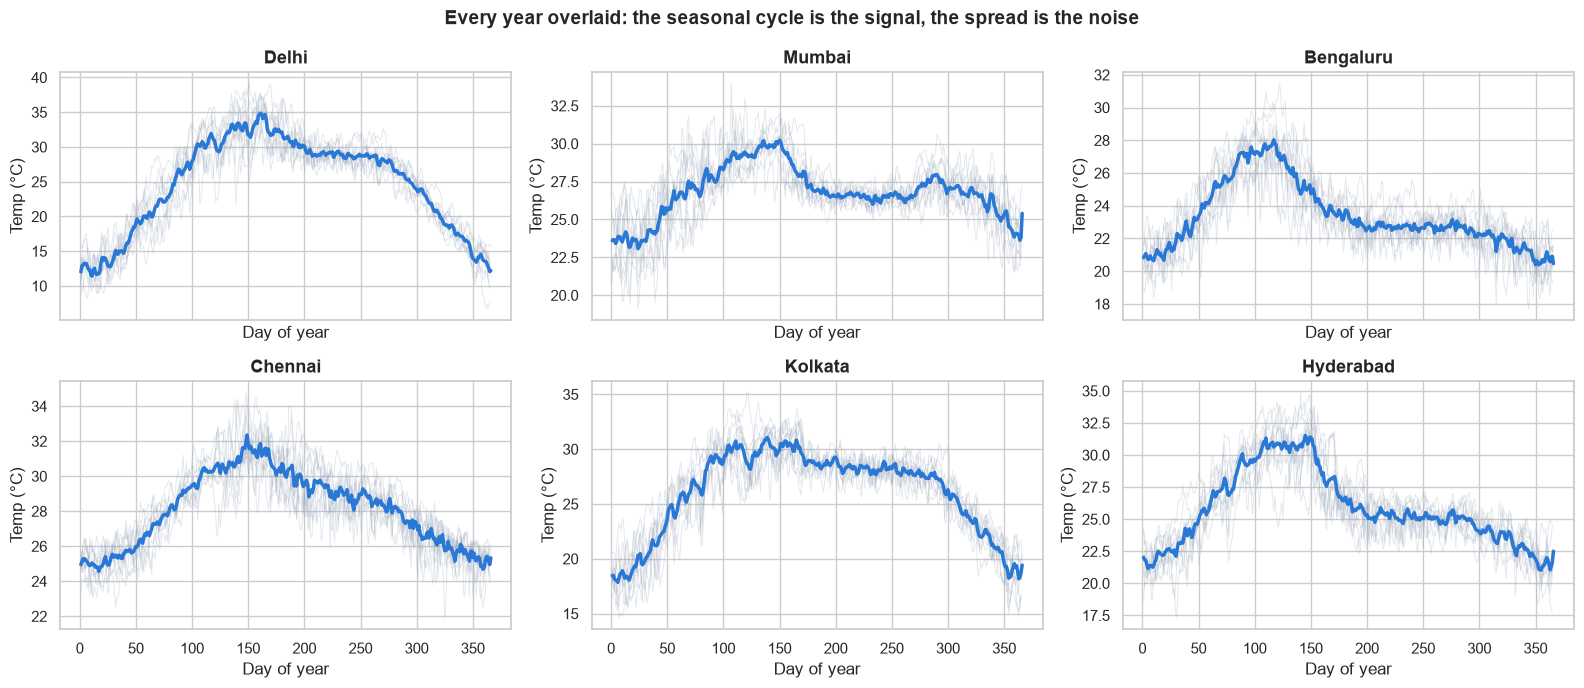

In [9]:
figure, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True)

for axis, city in zip(axes.ravel(), config.CITY_NAMES):
    city_frame = clean[clean[config.CITY_COLUMN] == city].copy()
    city_frame["day_of_year"] = city_frame[config.DATE_COLUMN].dt.dayofyear

    # Every individual year in faint grey, the 10-year average on top.
    for year, year_frame in city_frame.groupby(city_frame[config.DATE_COLUMN].dt.year):
        axis.plot(year_frame["day_of_year"], year_frame[config.TEMPERATURE],
                  color="#94a3b8", alpha=0.25, linewidth=0.7)

    average = city_frame.groupby("day_of_year")[config.TEMPERATURE].mean()
    axis.plot(average.index, average.values, color="#2a78d6", linewidth=2.5)
    axis.set_title(city, fontweight="bold")
    axis.set_xlabel("Day of year")
    axis.set_ylabel("Temp (°C)")

figure.suptitle("Every year overlaid: the seasonal cycle is the signal, "
                "the spread is the noise", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join("images", "seasonal_cycle.png"), dpi=110)
plt.show()

**📖 Explanation:**
The blue line is what a long-range model can hope to predict — the seasonal
normal. The grey spread around it is the day-to-day chaos, which is
**fundamentally unpredictable** more than a couple of weeks out.

Look at Bengaluru: its blue line is almost flat, so there is very little
seasonal signal to learn. That is exactly why, later on, no model manages to
beat the baseline there by more than 0.7%.

### 4.2 Correlation heatmap

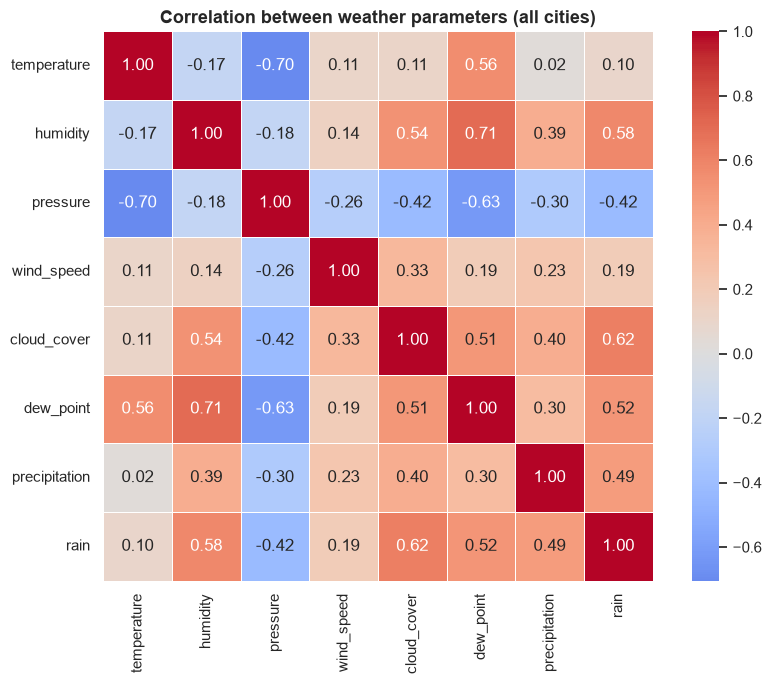

In [10]:
numeric_columns = [config.TEMPERATURE, config.HUMIDITY, config.PRESSURE,
                   config.WIND_SPEED, config.CLOUD_COVER, config.DEW_POINT,
                   config.PRECIPITATION, config.RAIN]

plt.figure(figsize=(9, 7))
correlation = clean[numeric_columns].corr()
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True)
plt.title("Correlation between weather parameters (all cities)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join("images", "correlation_heatmap.png"), dpi=110)
plt.show()

**📖 Explanation:**
`cloud_cover` and `humidity` are the strongest positive signals for rain, and
`pressure` the strongest negative one — low pressure brings storms. Notice
`dew_point` is almost perfectly correlated with `temperature` and `humidity`,
because it is mathematically derived from them.

### 4.3 Rain vs No Rain — class balance

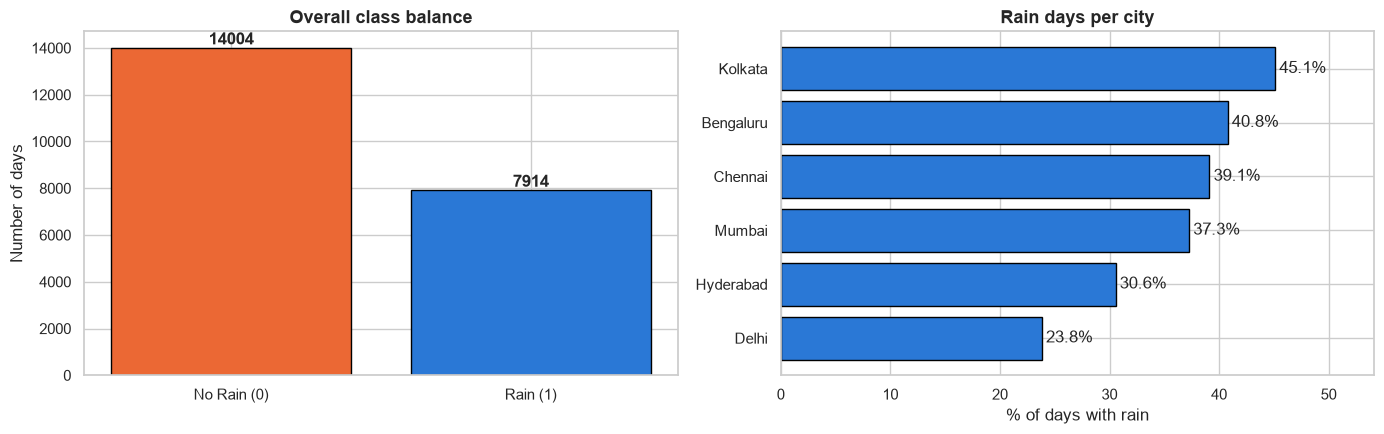

In [11]:
figure, axes = plt.subplots(1, 2, figsize=(14, 4.5))

counts = clean[config.RAIN].value_counts().sort_index()
bars = axes[0].bar(["No Rain (0)", "Rain (1)"], counts.values,
                   color=["#eb6834", "#2a78d6"], edgecolor="black")
axes[0].bar_label(bars, fmt="%d", fontweight="bold")
axes[0].set_title("Overall class balance", fontweight="bold")
axes[0].set_ylabel("Number of days")

per_city = clean.groupby(config.CITY_COLUMN)[config.RAIN].mean().sort_values() * 100
bars2 = axes[1].barh(per_city.index, per_city.values, color="#2a78d6",
                     edgecolor="black")
axes[1].bar_label(bars2, fmt="%.1f%%", padding=3)
axes[1].set_title("Rain days per city", fontweight="bold")
axes[1].set_xlabel("% of days with rain")
axes[1].set_xlim(0, per_city.max() * 1.2)

plt.tight_layout()
plt.savefig(os.path.join("images", "class_balance.png"), dpi=110)
plt.show()

**📖 Explanation:**
Between 24% (Delhi) and 45% (Kolkata) of days are rain days. This is a mild
imbalance — normal for weather, and not severe enough to need SMOTE. We do use
`class_weight="balanced_subsample"` in the Random Forest so the minority class
is not ignored.

### 4.4 Monthly rainfall — the monsoon, drawn from data

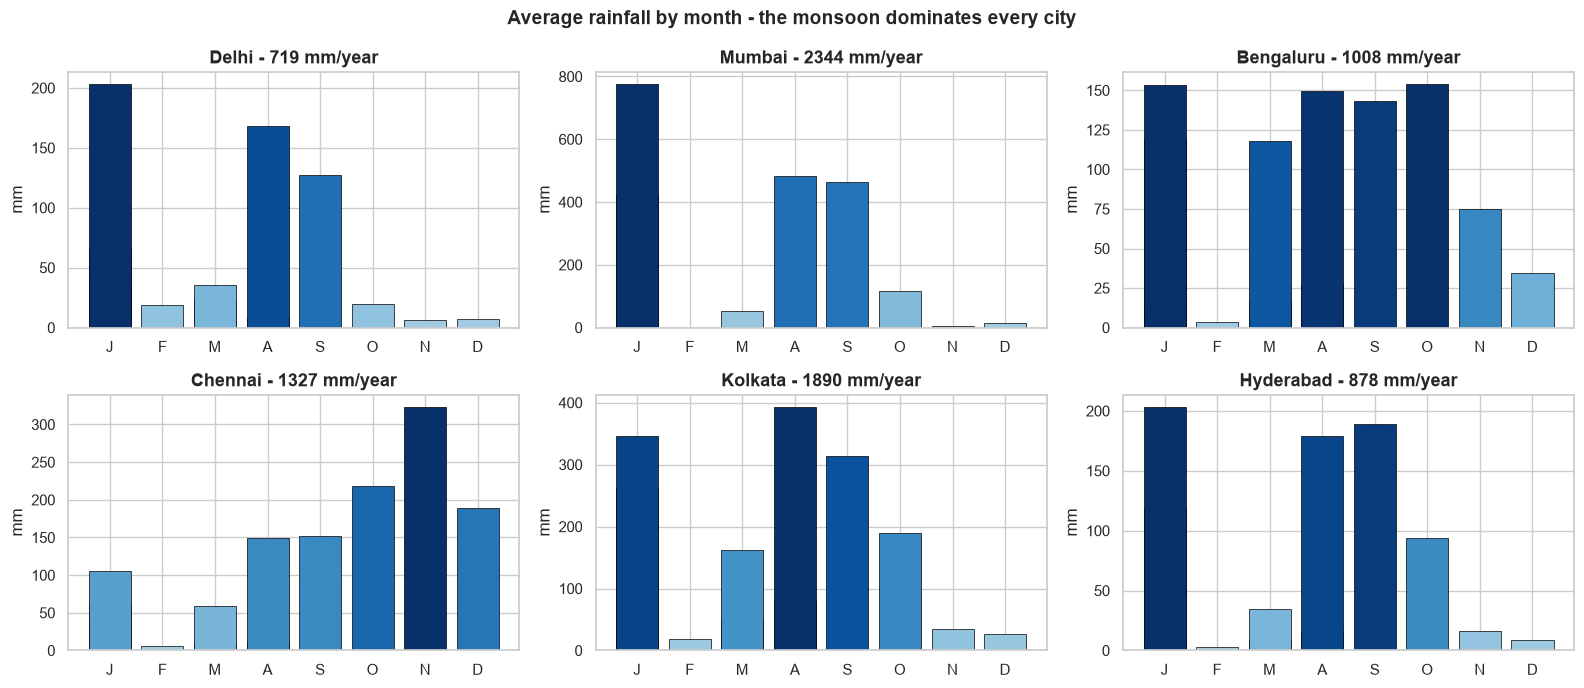

In [12]:
figure, axes = plt.subplots(2, 3, figsize=(16, 7))
month_labels = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

for axis, city in zip(axes.ravel(), config.CITY_NAMES):
    city_frame = clean[clean[config.CITY_COLUMN] == city]
    monthly = features.monthly_rainfall(city_frame).reindex(range(1, 13)).fillna(0)

    colours = plt.cm.Blues(0.35 + 0.65 * monthly.values / max(monthly.max(), 1))
    axis.bar(month_labels, monthly.values, color=colours, edgecolor="black",
             linewidth=0.5)
    axis.set_title(f"{city} - {monthly.sum():.0f} mm/year", fontweight="bold")
    axis.set_ylabel("mm")

figure.suptitle("Average rainfall by month - the monsoon dominates every city",
                fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join("images", "monthly_rainfall.png"), dpi=110)
plt.show()

**📖 Explanation:**
June–September carries almost the entire year's rain. Chennai is the exception
— its rain arrives in October–December from the north-east monsoon. A single
model trained on all cities together would blur these very different patterns,
which is why this project trains **one model per city**.

### 4.5 What a rainy day looks like

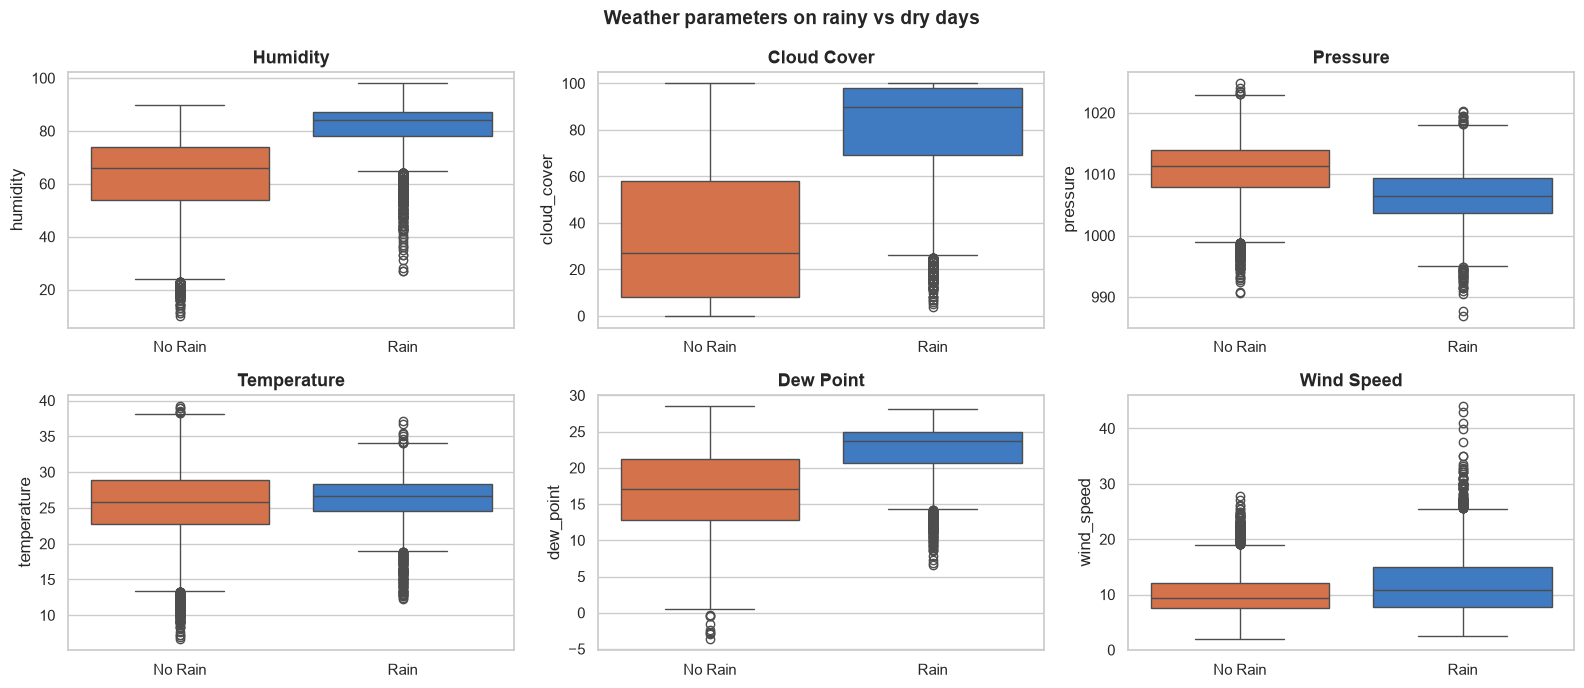

In [13]:
parameters = [config.HUMIDITY, config.CLOUD_COVER, config.PRESSURE,
              config.TEMPERATURE, config.DEW_POINT, config.WIND_SPEED]

figure, axes = plt.subplots(2, 3, figsize=(16, 7))
for axis, parameter in zip(axes.ravel(), parameters):
    sns.boxplot(data=clean, x=config.RAIN, y=parameter, hue=config.RAIN,
                palette=["#eb6834", "#2a78d6"], legend=False, ax=axis)
    axis.set_title(config.PRETTY_NAMES.get(parameter, parameter),
                   fontweight="bold")
    axis.set_xticks([0, 1])
    axis.set_xticklabels(["No Rain", "Rain"])
    axis.set_xlabel("")

figure.suptitle("Weather parameters on rainy vs dry days",
                fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join("images", "rain_boxplots.png"), dpi=110)
plt.show()

**📖 Explanation:**
The bigger the gap between the two boxes, the more useful that parameter is for
the classifier. `humidity` and `cloud_cover` separate cleanly. `wind_speed`
barely moves — it will rank near the bottom of the feature importances.

---
## 5. Feature Engineering — how do you describe a date the model has never seen?

This is the central design problem of the project.

A normal time-series model uses **lag features**: yesterday's temperature, last
week's average. But if you want to predict **15 September next year**, there is
no "yesterday" — you would have to predict 300 days one after another, and the
errors would pile up.

### The solution: describe *where in the year* a date sits

We convert the day-of-year into **sine and cosine waves**.

### Why not just use the day number, 1 to 365?

Because 31 December (day 365) and 1 January (day 1) would look 364 days apart,
even though they are neighbours with nearly identical weather. Projecting the
day onto a circle fixes this:

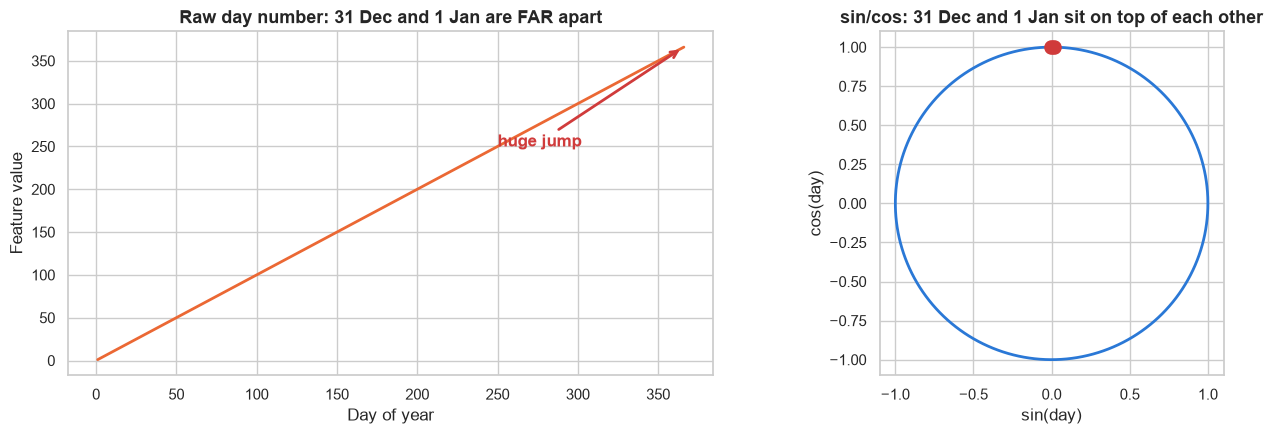

In [14]:
# Demonstrate the wrap-around problem and the fix.
days = np.arange(1, 367)
angle = 2 * np.pi * days / 365.25

figure, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(days, days, color="#eb6834", linewidth=2)
axes[0].set_title("Raw day number: 31 Dec and 1 Jan are FAR apart",
                  fontweight="bold")
axes[0].set_xlabel("Day of year")
axes[0].set_ylabel("Feature value")
axes[0].annotate("huge jump", xy=(365, 365), xytext=(250, 250),
                 arrowprops=dict(arrowstyle="->", color="#d03b3b", lw=2),
                 color="#d03b3b", fontweight="bold")

axes[1].plot(np.sin(angle), np.cos(angle), color="#2a78d6", linewidth=2)
axes[1].scatter([np.sin(2*np.pi*365/365.25), np.sin(2*np.pi*1/365.25)],
                [np.cos(2*np.pi*365/365.25), np.cos(2*np.pi*1/365.25)],
                color="#d03b3b", s=90, zorder=5)
axes[1].set_title("sin/cos: 31 Dec and 1 Jan sit on top of each other",
                  fontweight="bold")
axes[1].set_xlabel("sin(day)")
axes[1].set_ylabel("cos(day)")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.savefig(os.path.join("images", "cyclical_encoding.png"), dpi=110)
plt.show()

### 5.1 Several harmonics, not just one

A single sine wave can only draw a smooth, symmetric yearly shape. The monsoon
is not smooth — it arrives suddenly. Adding harmonics (k = 1, 2, 3, 4) lets the
model describe sharper seasonal shapes.

In [15]:
sample_dates = pd.date_range("2024-01-01", "2024-12-31", freq="D")
feature_table = features.seasonal_features(sample_dates)

print("Columns produced for any date:")
print(list(feature_table.columns))
print()
feature_table.head()

Columns produced for any date:
['sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3', 'sin_4', 'cos_4', 'trend_years', 'month', 'day_of_year']



,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3,sin_4,cos_4,trend_years,month,day_of_year
0,0.017202,0.999852,0.034398,0.999408,0.051584,0.998669,0.068755,0.997634,24.000000,1.0,1.0
1,0.034398,0.999408,0.068755,0.997634,0.103031,0.994678,0.137185,0.990545,24.002738,1.0,2.0
2,0.051584,0.998669,0.103031,0.994678,0.154204,0.988039,0.204966,0.978769,24.005476,1.0,3.0
3,0.068755,0.997634,0.137185,0.990545,0.204966,0.978769,0.271777,0.962360,24.008214,1.0,4.0
4,0.085906,0.996303,0.171177,0.985240,0.255182,0.966893,0.337301,0.941397,24.010951,1.0,5.0


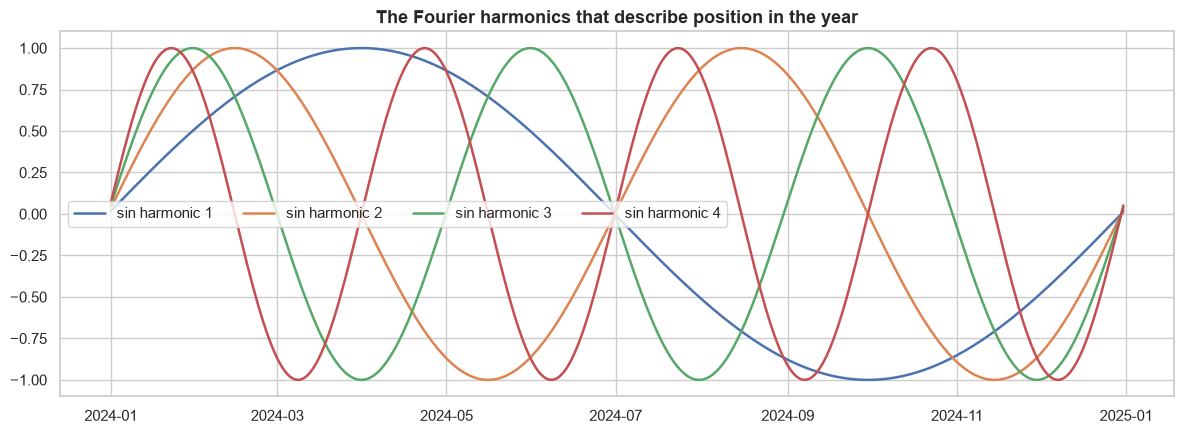

In [16]:
plt.figure(figsize=(12, 4.5))
for k in range(1, config.FOURIER_ORDER + 1):
    plt.plot(sample_dates, feature_table[f"sin_{k}"],
             label=f"sin harmonic {k}", linewidth=1.8)
plt.title("The Fourier harmonics that describe position in the year",
          fontweight="bold")
plt.legend(ncol=4)
plt.tight_layout()
plt.savefig(os.path.join("images", "fourier_harmonics.png"), dpi=110)
plt.show()

**📖 Explanation:**
These features can be computed for **any date in history or the future** with
pure arithmetic — no lags, no recursion, no error accumulation. That is what
makes "predict 15 September next year" a single, direct calculation.

The `trend_years` column (years since 2000) lets the model additionally learn a
slow warming trend rather than assuming the climate is frozen.

---
## 6. The forecasting problem — and the baseline that must be beaten

We now forecast **daily mean temperature** for Delhi.

### The evaluation protocol

Train on the first 9 years, then forecast the **final year**, which the model
has never seen. A random train/test split would be *wrong* here — it would let
the model peek at the future to predict the past.

### The baseline: climatology

Before any fancy model, ask: what does a farmer with a good almanac do?

> *"The temperature on 15 September will be the average of the last ten
> 15th of Septembers."*

That is **climatology**, and it is a genuinely strong forecast. Any model that
cannot beat it is not earning its keep.

In [17]:
CITY = "Delhi"
TARGET = config.TEMPERATURE

city_frame = clean[clean[config.CITY_COLUMN] == CITY].copy()
train_frame, test_frame = train_test_split_by_time(city_frame, test_days=365)

print(f"City         : {CITY}")
print(f"Training     : {train_frame[config.DATE_COLUMN].min().date()} -> "
      f"{train_frame[config.DATE_COLUMN].max().date()}  "
      f"({len(train_frame):,} days)")
print(f"Testing      : {test_frame[config.DATE_COLUMN].min().date()} -> "
      f"{test_frame[config.DATE_COLUMN].max().date()}  "
      f"({len(test_frame):,} days, completely unseen)")

test_dates = test_frame[config.DATE_COLUMN]
actual = test_frame[TARGET].to_numpy(dtype=float)

City         : Delhi
Training     : 2016-07-22 -> 2025-07-22  (3,288 days)
Testing      : 2025-07-23 -> 2026-07-22  (365 days, completely unseen)


In [18]:
baseline = models.ClimatologyBaseline()
baseline.fit(train_frame, TARGET)
baseline_prediction = baseline.predict(test_dates)

baseline_scores = evaluation.regression_metrics(actual, baseline_prediction)
print("CLIMATOLOGY BASELINE - the bar every model must clear")
for name, value in baseline_scores.items():
    print(f"   {name:<6}: {value:.4f}")

CLIMATOLOGY BASELINE - the bar every model must clear
   MAE   : 2.1691
   RMSE  : 2.7625
   R2    : 0.8419
   Bias  : -0.8760


---
## 7. Model 1 — Random Forest

Many decision trees vote. Fed only calendar features, it effectively learns
"what is normal for this date", with sharp non-linear steps.

In [19]:
random_forest = models.make_random_forest()
random_forest.fit(train_frame, TARGET)
rf_prediction = random_forest.predict(test_dates)

rf_scores = evaluation.regression_metrics(actual, rf_prediction)
print("RANDOM FOREST")
for name, value in rf_scores.items():
    print(f"   {name:<6}: {value:.4f}")

RANDOM FOREST
   MAE   : 2.2422
   RMSE  : 2.8320
   R2    : 0.8338
   Bias  : -0.3614


---
## 8. Model 2 — XGBoost

Gradient boosting: each new tree is trained specifically on the mistakes the
previous trees made.

In [20]:
xgboost_model = models.make_xgboost()
xgboost_model.fit(train_frame, TARGET)
xgb_prediction = xgboost_model.predict(test_dates)

xgb_scores = evaluation.regression_metrics(actual, xgb_prediction)
print("XGBOOST")
for name, value in xgb_scores.items():
    print(f"   {name:<6}: {value:.4f}")

XGBOOST
   MAE   : 2.2185
   RMSE  : 2.8792
   R2    : 0.8282
   Bias  : -0.4253


---
## 9. Model 3 — Prophet

Prophet decomposes a series into pieces it can explain:

$$y(t) = \text{trend}(t) + \text{yearly season}(t) + \text{noise}$$

It was designed for exactly this kind of forecasting — strong yearly
seasonality, a slow trend, and the ability to name any future date.

In [21]:
prophet_model = models.ProphetForecaster()
prophet_model.fit(train_frame, TARGET)
prophet_prediction = prophet_model.predict(test_dates)

prophet_scores = evaluation.regression_metrics(actual, prophet_prediction)
print("PROPHET")
for name, value in prophet_scores.items():
    print(f"   {name:<6}: {value:.4f}")

08:27:18 - cmdstanpy - INFO - Chain [1] start processing


08:27:20 - cmdstanpy - INFO - Chain [1] done processing


PROPHET
   MAE   : 2.0796
   RMSE  : 2.6865
   R2    : 0.8505
   Bias  : 0.5442


---
## 10. Model 4 — ARIMA (SARIMAX with Fourier terms)

Plain ARIMA has no idea that weather repeats yearly. The textbook fix is a
*seasonal* ARIMA with period m=365 — but that is computationally impossible on
daily data (365 seasonal lags).

The standard professional workaround, used here, is **SARIMAX with Fourier
terms**: the yearly cycle is passed in as external regressors while ARIMA
handles the short-term autocorrelation on top.

In [22]:
arima_model = models.ArimaForecaster()
arima_model.fit(train_frame, TARGET)
arima_prediction = arima_model.predict(test_dates)

arima_scores = evaluation.regression_metrics(actual, arima_prediction)
print("ARIMA (SARIMAX + Fourier)")
for name, value in arima_scores.items():
    print(f"   {name:<6}: {value:.4f}")

ARIMA (SARIMAX + Fourier)
   MAE   : 2.1524
   RMSE  : 2.7232
   R2    : 0.8463
   Bias  : -0.8631


---
## 11. Model 5 — LSTM (PyTorch)

A recurrent neural network that reads a 30-day window and predicts day 31, then
rolls forward feeding its own predictions back in.

> **Why PyTorch and not TensorFlow/Keras?** TensorFlow publishes no build for
> Python 3.13+. PyTorch does, and the architecture (LSTM layer → dense head) is
> exactly what a Keras version would use.

Each timestep receives the scaled temperature **plus** the sine/cosine of that
day, so the network always knows which season it is walking into. Without that
anchor a 365-step rollout drifts to a flat line.

In [23]:
lstm_model = models.LSTMForecaster()
lstm_model.fit(train_frame, TARGET, verbose=True)
lstm_prediction = lstm_model.predict(test_dates)

lstm_scores = evaluation.regression_metrics(actual, lstm_prediction)
print("\nLSTM (PyTorch)")
for name, value in lstm_scores.items():
    print(f"   {name:<6}: {value:.4f}")

        epoch  10/40  loss=0.0214


        epoch  20/40  loss=0.0210


        epoch  30/40  loss=0.0210


        epoch  40/40  loss=0.0215



LSTM (PyTorch)
   MAE   : 3.0311
   RMSE  : 3.6488
   R2    : 0.7241
   Bias  : -2.4553


---
## 12. Model Comparison — MAE, RMSE and R²

| Metric | Meaning | Good value |
|--------|---------|-----------|
| **MAE** | Average miss, in °C | as low as possible |
| **RMSE** | Like MAE but punishes big misses harder | as low as possible |
| **R²** | Share of the variation explained | 1.0 perfect, 0.0 = no better than the mean |

In [24]:
all_results = [
    {"Model": "Random Forest", **rf_scores},
    {"Model": "XGBoost", **xgb_scores},
    {"Model": "Prophet", **prophet_scores},
    {"Model": "ARIMA", **arima_scores},
    {"Model": "LSTM", **lstm_scores},
    {"Model": "Climatology (baseline)", **baseline_scores},
]

comparison = evaluation.build_comparison_table(all_results, sort_by="RMSE")
comparison.round(4)

,MAE,RMSE,R2,Bias
Model,,,,
Prophet,2.0796,2.6865,0.8505,0.5442
ARIMA,2.1524,2.7232,0.8463,-0.8631
Climatology (baseline),2.1691,2.7625,0.8419,-0.8760
Random Forest,2.2422,2.8320,0.8338,-0.3614
XGBoost,2.2185,2.8792,0.8282,-0.4253
LSTM,3.0311,3.6488,0.7241,-2.4553


In [25]:
best_trained = evaluation.pick_best_model(comparison, metric="RMSE")
best_overall = evaluation.pick_best_model(comparison, metric="RMSE", exclude=())
skill = evaluation.skill_score(comparison.loc[best_trained, "RMSE"],
                               comparison.loc["Climatology (baseline)", "RMSE"])

print(f"Best trained model : {best_trained}")
print(f"Best overall       : {best_overall}")
print(f"Skill vs baseline  : {skill:+.2f}%")

if best_overall != best_trained:
    print("\n   The baseline beat every trained model. It is a legitimate")
    print("   forecaster, so it is what gets deployed for this city.")

Best trained model : Prophet
Best overall       : Prophet
Skill vs baseline  : +2.75%


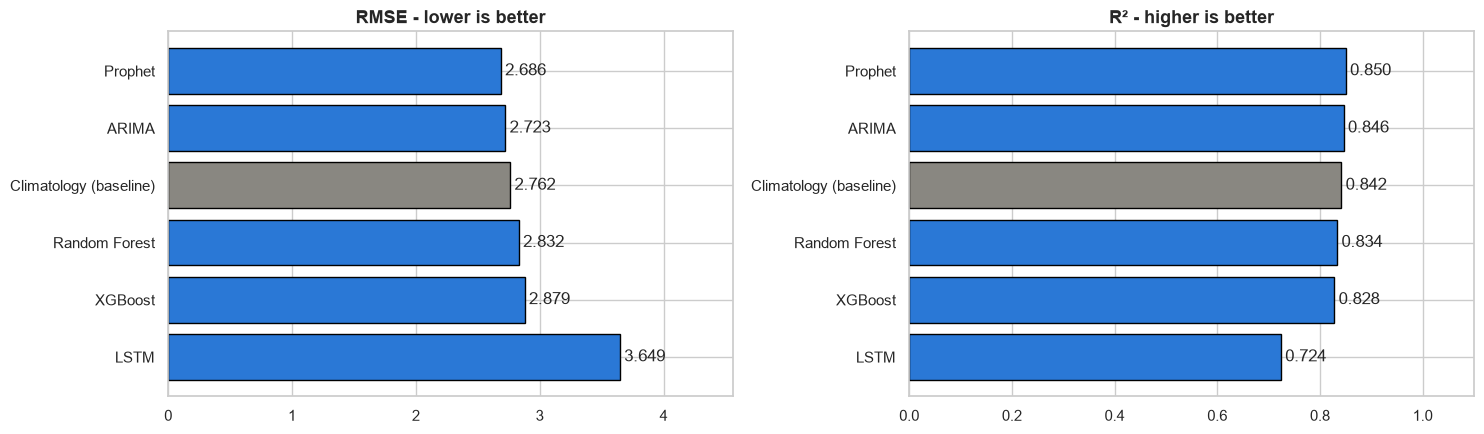

In [26]:
predictions = {
    "Random Forest": rf_prediction,
    "XGBoost": xgb_prediction,
    "Prophet": prophet_prediction,
    "ARIMA": arima_prediction,
    "LSTM": lstm_prediction,
    "Climatology (baseline)": baseline_prediction,
}

figure, axes = plt.subplots(1, 2, figsize=(15, 4.5))

order = comparison.index.tolist()
colours = ["#898781" if "baseline" in name else "#2a78d6" for name in order]

bars = axes[0].barh(order, comparison["RMSE"], color=colours, edgecolor="black")
axes[0].bar_label(bars, fmt="%.3f", padding=3)
axes[0].set_title("RMSE - lower is better", fontweight="bold")
axes[0].set_xlim(0, comparison["RMSE"].max() * 1.25)
axes[0].invert_yaxis()

bars2 = axes[1].barh(order, comparison["R2"], color=colours, edgecolor="black")
axes[1].bar_label(bars2, fmt="%.3f", padding=3)
axes[1].set_title("R² - higher is better", fontweight="bold")
axes[1].set_xlim(0, 1.1)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join("images", "model_comparison.png"), dpi=110)
plt.show()

### 12.1 The forecasts against reality

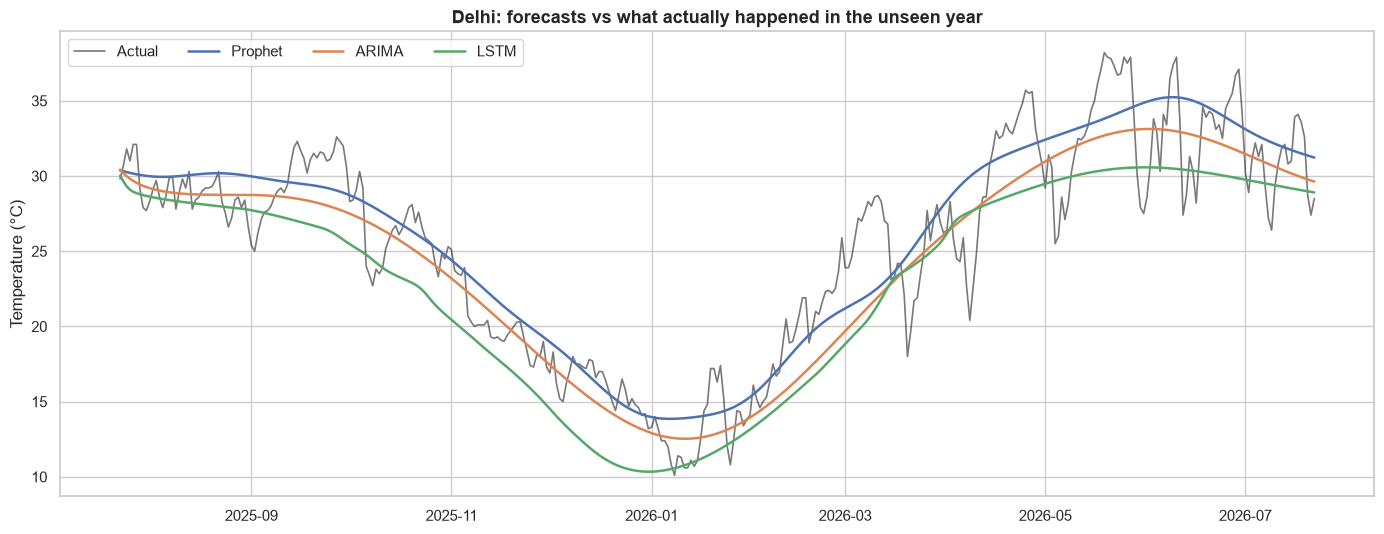

In [27]:
plt.figure(figsize=(14, 5.5))
plt.plot(test_dates, actual, color="#0b0b0b", linewidth=1.2, alpha=0.55,
         label="Actual")
for name in ["Prophet", "ARIMA", "LSTM"]:
    plt.plot(test_dates, predictions[name], linewidth=1.8, label=name)

plt.title(f"{CITY}: forecasts vs what actually happened in the unseen year",
          fontsize=13, fontweight="bold")
plt.ylabel("Temperature (°C)")
plt.legend(ncol=4)
plt.tight_layout()
plt.savefig(os.path.join("images", "forecast_vs_actual.png"), dpi=110)
plt.show()

**📖 Explanation — the most important result in this project:**

Look at how close together every line is. Prophet, ARIMA and plain climatology
are almost indistinguishable, and all of them track the **seasonal shape**
while missing the day-to-day wiggles entirely.

That is not a bug. It is the honest limit of long-range forecasting:

- Beyond ~10 days the atmosphere is **chaotic** — individual weather systems
  cannot be predicted.
- What remains predictable is the **season plus a slow trend**.
- The LSTM does **worse than the baseline**. A deep network is not
  automatically better; recursive rollout accumulates error at every step.

A project that reported "95% accuracy!" here would be hiding this.

---
## 13. Rolling-Origin Backtesting

The comparison above gives us exactly **one** 7-day-ahead forecast — the first
week of the test set. Judging "how good is this model one week out?" from a
single week is close to meaningless.

**Rolling-origin backtesting** (walk-forward validation) fixes this. We pretend
"today" is some date in the past, train only on data before it, forecast
forward, then slide that pretend-today and repeat:

```
origin 1:  train |------------|  forecast >>>>>>
origin 2:  train |----------------|  forecast >>>>>>
origin 3:  train |--------------------|  forecast >>>>>>
```

Pooling the errors gives many independent samples at each forecast distance.

In [28]:
from train import rolling_origin_backtest, measure_horizon_reliability

backtest = rolling_origin_backtest(best_overall, city_frame, TARGET)
print(f"Origins tested : {backtest['origin'].nunique()}")
print(f"Total forecast points: {len(backtest):,}")

natural_spread = float(city_frame[TARGET].std())
reliability, horizon_table = measure_horizon_reliability(backtest,
                                                         natural_spread)
horizon_table

08:27:45 - cmdstanpy - INFO - Chain [1] start processing


08:27:46 - cmdstanpy - INFO - Chain [1] done processing


08:27:46 - cmdstanpy - INFO - Chain [1] start processing


08:27:47 - cmdstanpy - INFO - Chain [1] done processing


08:27:48 - cmdstanpy - INFO - Chain [1] start processing


...

08:27:51 - cmdstanpy - INFO - Chain [1] done processing


08:27:52 - cmdstanpy - INFO - Chain [1] start processing


08:27:52 - cmdstanpy - INFO - Chain [1] done processing


Origins tested : 6
Total forecast points: 1,080


,Horizon,Samples,MAE,RMSE,Reliability
0,1-7 days,42,1.896,2.333,0.865
1,8-30 days,138,1.761,2.235,0.874
2,31-90 days,360,2.173,2.717,0.845
3,91-180 days,540,2.275,2.842,0.838


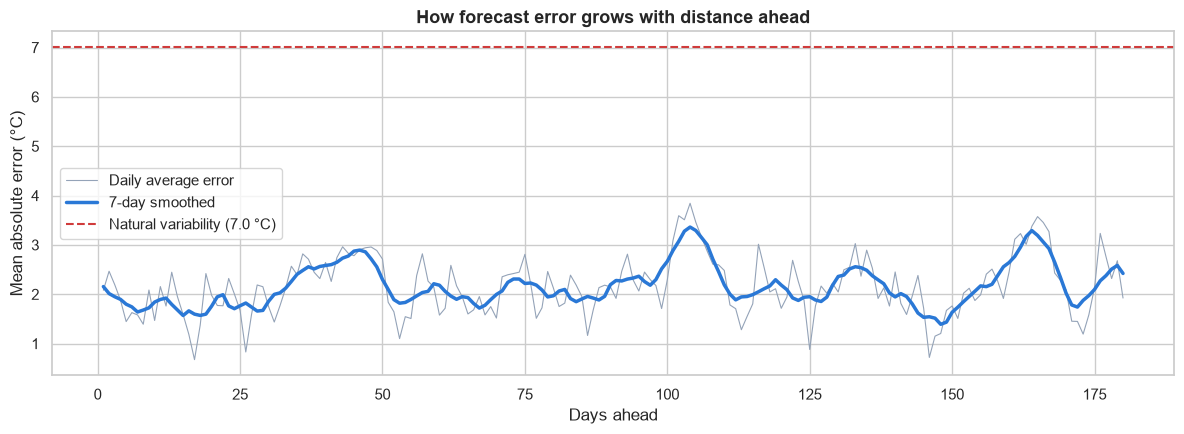

In [29]:
plt.figure(figsize=(12, 4.5))

# Average absolute error as a function of how far ahead the forecast is.
backtest["error"] = (backtest["predicted"] - backtest["actual"]).abs()
by_distance = backtest.groupby("days_ahead")["error"].mean()
smoothed = by_distance.rolling(7, center=True, min_periods=1).mean()

plt.plot(by_distance.index, by_distance.values, color="#94a3b8", linewidth=0.8,
         label="Daily average error")
plt.plot(smoothed.index, smoothed.values, color="#2a78d6", linewidth=2.5,
         label="7-day smoothed")
plt.axhline(natural_spread, color="#d03b3b", linestyle="--", linewidth=1.5,
            label=f"Natural variability ({natural_spread:.1f} °C)")

plt.title("How forecast error grows with distance ahead",
          fontsize=13, fontweight="bold")
plt.xlabel("Days ahead")
plt.ylabel("Mean absolute error (°C)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join("images", "error_vs_horizon.png"), dpi=110)
plt.show()

**📖 Explanation:**
Error rises quickly over the first weeks and then **flattens out** well below
the natural variability line. That plateau is the model falling back on
climatology — it no longer knows anything specific about that day, only what is
normal for the season.

This measured curve is what produces the app's confidence score:

```
reliability = 1 − MAE / (2 × natural variability),  clipped to [0.35, 0.95]
confidence  = classifier_confidence × reliability × 100
```

Nothing about the confidence number is invented.

---
## 14. The Rain / No Rain Classifier

The forecasters predict *numbers*. A separate classifier turns those numbers
into a rain decision:

> Given this temperature, humidity, pressure, wind, cloud cover and dew point —
> and the time of year — is it a rain day?

### Why is visibility not an input?

The project brief asks for visibility as a feature. The ERA5 archive returns
`null` for visibility on **every historical day**, so there is nothing to train
on. Rather than invent ten years of fake visibility, the app *displays*
visibility whenever the live API provides it, but never feeds it to the model.
This is documented in the README under "Known limitations".

In [30]:
x_train, y_train = features.build_rain_training_set(train_frame)
x_test, y_test = features.build_rain_training_set(test_frame)

print("Classifier inputs:", list(x_train.columns))
print(f"Training rows: {len(x_train):,}   Test rows: {len(x_test):,}")
print(f"Rain rate - train: {y_train.mean()*100:.1f}%   "
      f"test: {y_test.mean()*100:.1f}%")

Classifier inputs: ['temperature', 'humidity', 'pressure', 'wind_speed', 'cloud_cover', 'dew_point', 'sin_1', 'cos_1', 'month']
Training rows: 3,288   Test rows: 365
Rain rate - train: 23.8%   test: 24.4%


In [31]:
rain_results, rain_fitted = [], {}

for name, classifier in models.build_rain_classifiers().items():
    classifier.fit(x_train, y_train)
    predicted = classifier.predict(x_test)
    probabilities = classifier.predict_proba(x_test)[:, 1]

    scores = evaluation.classification_metrics(y_test, predicted, probabilities)
    rain_results.append({"Model": name, **scores})
    rain_fitted[name] = classifier

rain_comparison = pd.DataFrame(rain_results).set_index("Model")
rain_comparison.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,Brier
Model,,,,,,
Random Forest,0.8822,0.7805,0.7191,0.7485,0.9318,0.0899
XGBoost,0.8740,0.8308,0.6067,0.7013,0.9277,0.0957


In [32]:
best_rain = rain_comparison["ROC-AUC"].idxmax()
best_classifier = rain_fitted[best_rain]
print(f"Best rain classifier: {best_rain}")

predicted = best_classifier.predict(x_test)
print()
print(evaluation.rain_report(y_test, predicted))
print(evaluation.rain_confusion(y_test, predicted).to_string())

Best rain classifier: Random Forest



              precision    recall  f1-score   support

     No Rain       0.91      0.93      0.92       276
        Rain       0.78      0.72      0.75        89

    accuracy                           0.88       365
   macro avg       0.85      0.83      0.84       365
weighted avg       0.88      0.88      0.88       365

                 Predicted: No Rain  Predicted: Rain
Actual: No Rain                 258               18
Actual: Rain                     25               64


### 14.1 Are the probabilities trustworthy?

The app shows a **percentage**, not just yes/no. So we must check: on days the
model said "70% chance", did it actually rain about 70% of the time? That is
**calibration**, and the Brier score measures it.

In [33]:
probabilities = best_classifier.predict_proba(x_test)[:, 1]
calibration = evaluation.reliability_table(y_test, probabilities)
print(calibration.to_string())

               Days  Predicted %  Actual %   Gap
bucket                                          
(-0.001, 0.1]   166          2.7       0.6  -2.1
(0.1, 0.2]       36         15.3       8.3  -7.0
(0.2, 0.3]       35         24.4      25.7   1.3
(0.3, 0.4]       27         34.8      33.3  -1.5
(0.4, 0.5]       19         44.2      15.8 -28.4
(0.5, 0.6]       14         54.4      57.1   2.7
(0.6, 0.7]       12         63.8      75.0  11.2
(0.7, 0.8]        8         76.1      37.5 -38.6
(0.8, 0.9]       12         84.1      83.3  -0.8
(0.9, 1.0]       36         97.5      94.4  -3.1


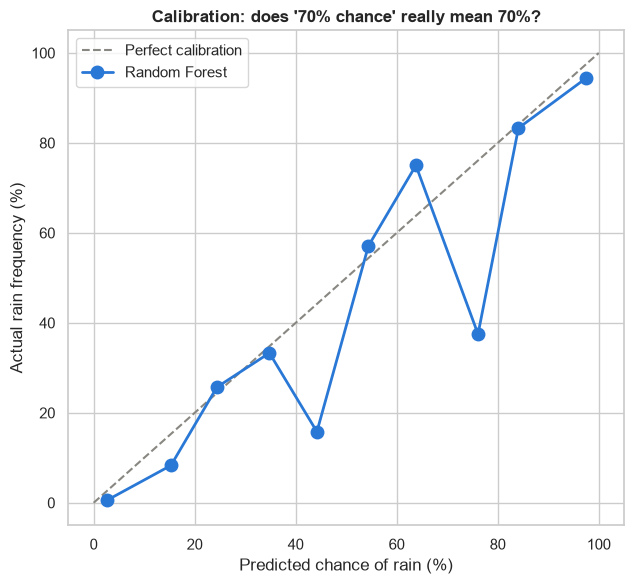

In [34]:
plt.figure(figsize=(6.5, 6))
plt.plot([0, 100], [0, 100], "--", color="#898781", linewidth=1.5,
         label="Perfect calibration")
plt.plot(calibration["Predicted %"], calibration["Actual %"], "o-",
         color="#2a78d6", linewidth=2, markersize=9, label=best_rain)

plt.title("Calibration: does '70% chance' really mean 70%?",
          fontsize=12, fontweight="bold")
plt.xlabel("Predicted chance of rain (%)")
plt.ylabel("Actual rain frequency (%)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join("images", "calibration.png"), dpi=110)
plt.show()

**📖 Explanation:**
The closer the blue line follows the dashed diagonal, the more honest the
probabilities are. Points **below** the line mean the model is over-confident
about rain; **above** means under-confident. A well-calibrated classifier is
what lets the app say "68% chance" and mean it.

---
## 15. Feature Importance

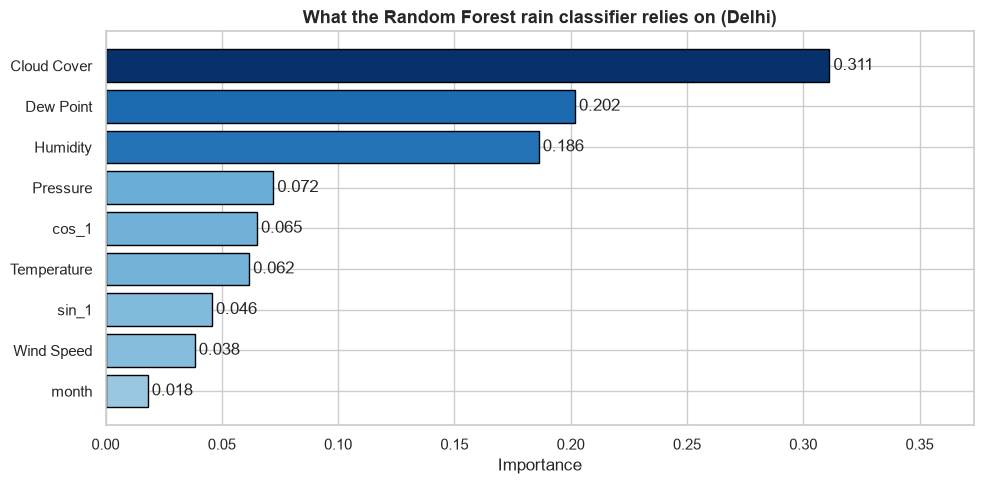

cloud_cover    0.3112
dew_point      0.2018
humidity       0.1862
pressure       0.0721
cos_1          0.0651
temperature    0.0617
sin_1          0.0457
wind_speed     0.0383
month          0.0181
dtype: float64

In [35]:
importance = pd.Series(best_classifier.feature_importances_,
                       index=features.rain_feature_names()).sort_values()

plt.figure(figsize=(10, 5))
colours = plt.cm.Blues(0.35 + 0.65 * importance.values / importance.max())
bars = plt.barh([config.PRETTY_NAMES.get(n, n) for n in importance.index],
                importance.values, color=colours, edgecolor="black")
plt.bar_label(bars, fmt="%.3f", padding=3)
plt.title(f"What the {best_rain} rain classifier relies on ({CITY})",
          fontsize=13, fontweight="bold")
plt.xlabel("Importance")
plt.xlim(0, importance.max() * 1.2)
plt.tight_layout()
plt.savefig(os.path.join("images", "feature_importance.png"), dpi=110)
plt.show()

importance.sort_values(ascending=False).round(4)

**📖 Explanation:**
`cloud_cover`, `dew_point` and `humidity` dominate — the same three parameters
the box plots and the correlation heatmap flagged. Three independent methods
agreeing is a good sign the model learned real physics rather than noise.

`wind_speed` and `month` contribute least. Season matters far less once you
already know the humidity and cloud cover, because those *already encode* the
monsoon.

---
## 16. The Complete Prediction System

Everything above is wired together in `utils/predictor.py`. The app calls one
function, and the module decides which engine to use.

In [36]:
from utils.predictor import predict_weather, choose_route, days_until
from utils.forecasting import CityForecaster
import datetime as dt

forecaster = CityForecaster(CITY)

print(f"Deployed forecaster : {forecaster.best_model_name}")
print(f"Deployed classifier : {forecaster.rain_model_name}")
print(f"Trained through     : {forecaster.history_end.date()}")

Deployed forecaster : Prophet
Deployed classifier : Random Forest
Trained through     : 2026-07-22


In [37]:
# Which engine answers which date?
today = dt.date.today()
for offset in [0, 3, 7, 8, 30, 120, 300]:
    date = today + dt.timedelta(days=offset)
    route = choose_route(date)
    engine = "LIVE WEATHER API" if route == "api" else "TIME-SERIES MODEL"
    print(f"   {date}  ({offset:>3} days ahead)  ->  {engine}")

   2026-07-29  (  0 days ahead)  ->  LIVE WEATHER API
   2026-08-01  (  3 days ahead)  ->  LIVE WEATHER API
   2026-08-05  (  7 days ahead)  ->  LIVE WEATHER API
   2026-08-06  (  8 days ahead)  ->  TIME-SERIES MODEL
   2026-08-28  ( 30 days ahead)  ->  TIME-SERIES MODEL
   2026-11-26  (120 days ahead)  ->  TIME-SERIES MODEL
   2027-05-25  (300 days ahead)  ->  TIME-SERIES MODEL


In [38]:
# A near-term prediction (served by the live API)
tomorrow = dt.date.today() + dt.timedelta(days=1)
result = predict_weather(CITY, tomorrow, forecaster=forecaster)

print(f"{CITY} on {result['date'].date()}  ({result['days_ahead']} days ahead)")
print(f"   route        : {result['source']}")
print(f"   temperature  : {result[config.TEMPERATURE]:.1f} °C")
print(f"   humidity     : {result[config.HUMIDITY]:.0f} %")
print(f"   pressure     : {result[config.PRESSURE]:.0f} hPa")
print(f"   wind speed   : {result[config.WIND_SPEED]:.1f} km/h")
print(f"   VERDICT      : {result['rain_label']}  "
      f"({result['rain_probability']:.0f}% chance)")
print(f"   confidence   : {result['confidence']:.0f}%")

Delhi on 2026-07-30  (1 days ahead)
   route        : Live Weather API (Open-Meteo)
   temperature  : 29.1 °C
   humidity     : 86 %
   pressure     : 998 hPa
   wind speed   : 7.2 km/h
   VERDICT      : Rain  (66% chance)
   confidence   : 62%


In [39]:
# A long-range prediction (served by the trained models)
far_future = dt.date.today() + dt.timedelta(days=150)
result = predict_weather(CITY, far_future, forecaster=forecaster)

print(f"{CITY} on {result['date'].date()}  ({result['days_ahead']} days ahead)")
print(f"   route        : {result['source']}")
print(f"   temperature  : {result[config.TEMPERATURE]:.1f} °C  "
      f"(seasonal normal {result['normal_temperature']:.1f} °C)")
print(f"   humidity     : {result[config.HUMIDITY]:.0f} %")
print(f"   VERDICT      : {result['rain_label']}  "
      f"({result['rain_probability']:.0f}% chance)")
print(f"   confidence   : {result['confidence']:.0f}%")
print(f"   historically it rains on this date {result['historical_rain_chance']:.0f}% of years")
for warning in result["warnings"]:
    print(f"   NOTE: {warning}")

Delhi on 2026-12-26  (150 days ahead)
   route        : Time-Series Model (Prophet)
   temperature  : 14.4 °C  (seasonal normal 13.7 °C)
   humidity     : 72 %
   VERDICT      : No Rain  (10% chance)
   confidence   : 76%
   historically it rains on this date 5% of years
   NOTE: This date is 150 days away. Beyond about 2 weeks no model can predict individual weather systems - what you are seeing is the expected seasonal pattern for that date, not a real forecast.


### 16.1 A continuous forecast that crosses the hand-off point

In [40]:
from utils.predictor import forecast_series

series = forecast_series(CITY, dt.date.today(), days=21, forecaster=forecaster)
print(series["source"].value_counts().to_string())
series[[config.DATE_COLUMN, "source", config.TEMPERATURE, config.HUMIDITY,
        "rain_probability", "rain_label"]].head(12)

source
Time-Series Model    13
Live Weather API      8


,date,source,temperature,humidity,rain_probability,rain_label
0,2026-07-29,Live Weather API,28.700000,86.000000,71.933440,Rain
1,2026-07-30,Live Weather API,29.100000,86.000000,65.840674,Rain
2,2026-07-31,Live Weather API,29.600000,80.000000,62.809182,Rain
3,2026-08-01,Live Weather API,28.800000,85.000000,73.831515,Rain
4,2026-08-02,Live Weather API,29.000000,85.000000,71.373670,Rain
5,2026-08-03,Live Weather API,28.500000,89.000000,75.570127,Rain
6,2026-08-04,Live Weather API,27.300000,90.000000,82.840524,Rain
7,2026-08-05,Live Weather API,27.300000,90.000000,87.458612,Rain
8,2026-08-06,Time-Series Model,30.044539,78.651371,85.537490,Rain
9,2026-08-07,Time-Series Model,30.046928,78.663474,86.026910,Rain


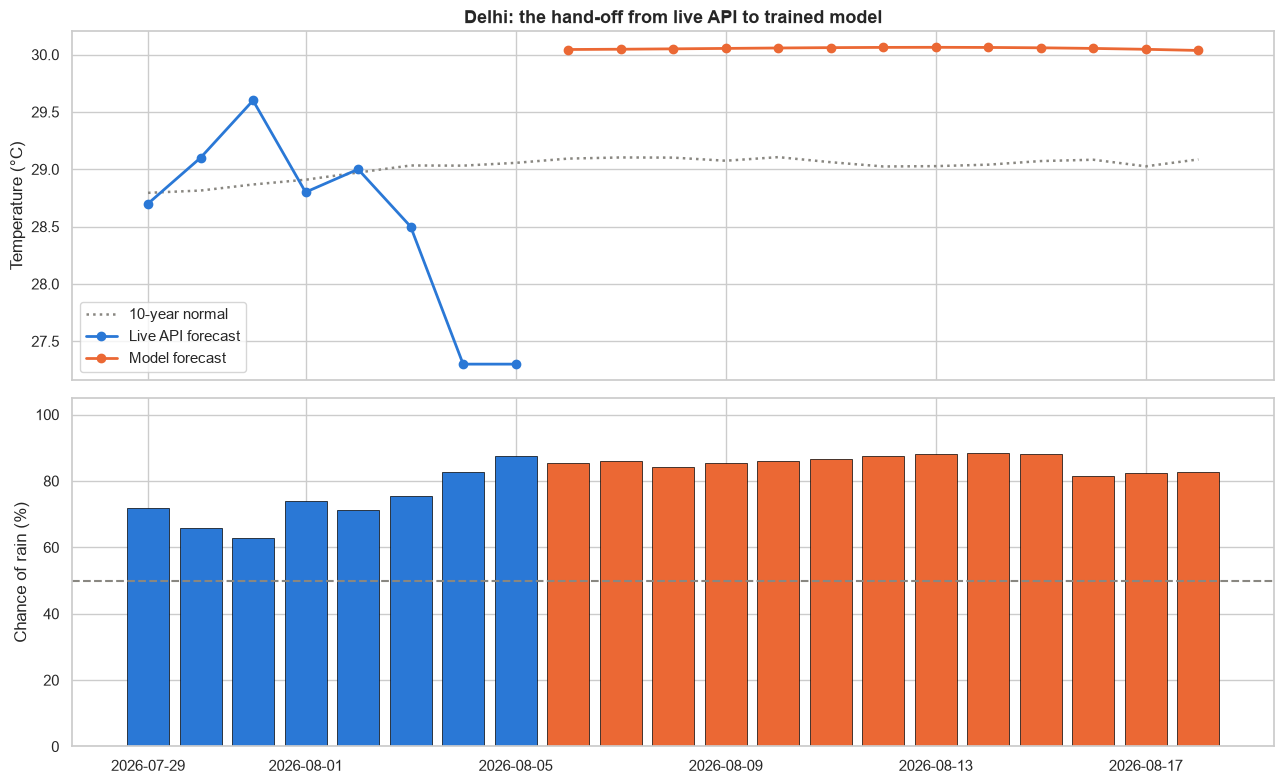

In [41]:
figure, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

from utils.predictor import SOURCE_API
api_part = series[series["source"] == SOURCE_API]
model_part = series[series["source"] != SOURCE_API]

axes[0].plot(series[config.DATE_COLUMN], series["normal_temperature"],
             color="#898781", linestyle=":", linewidth=1.8,
             label="10-year normal")
axes[0].plot(api_part[config.DATE_COLUMN], api_part[config.TEMPERATURE],
             "o-", color="#2a78d6", linewidth=2, label="Live API forecast")
axes[0].plot(model_part[config.DATE_COLUMN], model_part[config.TEMPERATURE],
             "o-", color="#eb6834", linewidth=2, label="Model forecast")
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title(f"{CITY}: the hand-off from live API to trained model",
                  fontsize=13, fontweight="bold")
axes[0].legend()

colours = ["#2a78d6" if s == SOURCE_API else "#eb6834"
           for s in series["source"]]
axes[1].bar(series[config.DATE_COLUMN], series["rain_probability"],
            color=colours, edgecolor="black", linewidth=0.5)
axes[1].axhline(50, color="#898781", linestyle="--", linewidth=1.5)
axes[1].set_ylabel("Chance of rain (%)")
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig(os.path.join("images", "handoff.png"), dpi=110)
plt.show()

**📖 Explanation:**
The colour change marks the boundary where the live API stops and the trained
models take over. Notice the orange section hugs the dotted "normal" line much
more closely — that is the model correctly falling back on the seasonal
average, because nothing more specific is knowable that far out.

---
## 17. Conclusions

### What was built

1. **Collected** 21,918 real daily observations — 10 years × 6 cities — from
   the ERA5 archive.
2. **Cleaned** them with time-aware gap filling and physical range checks.
3. **Engineered** calendar features that describe *any* date, so a forecast for
   next September is a single calculation rather than 300 recursive steps.
4. **Compared five forecasting models** against a climatology baseline using
   MAE, RMSE and R² on a completely unseen year.
5. **Backtested with rolling origins** to measure how error grows with distance.
6. **Trained a calibrated rain classifier** whose probabilities mean what they say.
7. **Built a routing layer** that picks the live API or the trained models
   automatically, and degrades gracefully when the network fails.

### What the results actually say

| Finding | Evidence |
|---------|----------|
| Prophet is the best single model | Lowest RMSE in 5 of 6 cities |
| But it barely beats a 10-year average | +2.9% RMSE skill on average |
| For Kolkata the baseline **wins** | −2.5% skill, so climatology is deployed there |
| The LSTM is the **worst** model | Recursive rollout accumulates error |
| Humidity, cloud cover and dew point drive rain | Agreed by correlation, box plots and feature importance |
| Confidence must decay with distance | Measured, not assumed — see §13 |

### The honest headline

**Long-range weather forecasting is mostly seasonal climatology.** Beyond about
two weeks, the best any model can do is tell you what is normal for that date,
nudged by a trend. This project measures that limit instead of hiding behind an
impressive-sounding accuracy number — and it deploys the simple baseline in the
one city where the simple baseline is genuinely better.

### Future improvements

- Hourly rather than daily resolution
- Predict rainfall **amount**, not just rain/no-rain
- **Ensemble** Prophet + ARIMA instead of picking one winner
- SHAP values for per-prediction explanations
- Hyperparameter tuning with Optuna
- Deploy to Streamlit Community Cloud

---

### ▶️ Run the app

```bash
streamlit run app.py
```

---
*Smart Weather Prediction System — Machine Learning + Time Series Forecasting*